## Step 1: Imports

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")

All libraries imported successfully
NumPy  : 2.4.6
Pandas : 3.0.3


## Step 2: Load Dataset

In [17]:
df = pd.read_csv('../data/kc_house_data.csv')

print(f"Shape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
df.head()

Shape    : (21613, 21)
Columns  : ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


## Step 3: Inspection

In [18]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (21613, 21)

Data Types:
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Missing Values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [31]:
print("\nUnique Values per Column: method 2")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique -> {df[col].unique()}")


Unique Values per Column: method 2
  price: 4028 unique -> [ 221900.  538000.  180000. ...  610685. 1007500.  402101.]
  bedrooms: 12 unique -> [ 3  2  4  5  1  6  7  0  8  9 11 10]
  bathrooms: 30 unique -> [1.   2.25 3.   2.   4.5  1.5  2.5  1.75 2.75 3.25 4.   3.5  0.75 4.75
 5.   4.25 3.75 0.   1.25 5.25 6.   0.5  5.5  6.75 5.75 8.   7.5  7.75
 6.25 6.5 ]
  sqft_living: 1038 unique -> [1180 2570  770 ... 3087 3118 1425]
  sqft_lot: 9782 unique -> [ 5650  7242 10000 ...  5813  2388  1076]
  floors: 6 unique -> [1.  2.  1.5 3.  2.5 3.5]
  waterfront: 2 unique -> [0 1]
  view: 5 unique -> [0 3 4 2 1]
  condition: 5 unique -> [3 5 4 1 2]
  grade: 12 unique -> [ 7  6  8 11  9  5 10 12  4  3 13  1]
  sqft_above: 946 unique -> [1180 2170  770 1050 1680 3890 1715 1060 1890 1860  860 1430 1370 1810
 1980 1600 1200 1250 2330 2270 1070 2450 1710 1750 1400  790 2570 2320
 1190 1510 1090 1280  930 2360  890 2620 2600 3595 1570  920 3160  990
 2290 2165 1640 1000 2130 2830 2250 2420 3250 1850 1

In [20]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4580301520.86,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2876565571.31,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1000102.00,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2123049194.00,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3904930410.00,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7308900445.00,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9900000190.00,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.31,6210.00,871200.00


## Step 4: Cleaning


In [ ]:
#Drop columns
df.drop(columns=['id', 'zipcode'], inplace=True)
print("Shape:", df.shape)

Shape: (21613, 19)


In [22]:
#Extract date features
df['sale_year'] = df['date'].str[:4].astype(int)
df['sale_month'] = df['date'].str[4:6].astype(int)
df.drop(columns=['date'], inplace=True)
print("Shape:", df.shape)

Shape: (21613, 20)


In [23]:
#Remove bedrooms == 33
print("Before:", df.shape)
df = df[df['bedrooms'] != 33]
print("After removing bedrooms==33:", df.shape)

Before: (21613, 20)
After removing bedrooms==33: (21612, 20)


In [24]:
#Engineer house_age and is_renovated
df['house_age'] = 2015 - df['yr_built']
df['is_renovated'] = (df['yr_renovated'] != 0).astype(int)
df.drop(columns=['yr_built', 'yr_renovated'], inplace=True)
print("Shape:", df.shape)

Shape: (21612, 20)


In [25]:
#Clean column names
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
print("Columns:", list(df.columns))
df.head()

Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age', 'is_renovated']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,is_renovated
0,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,47.51,-122.26,1340,5650,2014,10,60,0
1,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,47.72,-122.32,1690,7639,2014,12,64,1
2,180000.00,2,1.00,770,10000,1.00,0,0,3,6,770,0,47.74,-122.23,2720,8062,2015,2,82,0
3,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,47.52,-122.39,1360,5000,2014,12,50,0
4,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,47.62,-122.05,1800,7503,2015,2,28,0


## Step 5: Exploratory Data Analysis

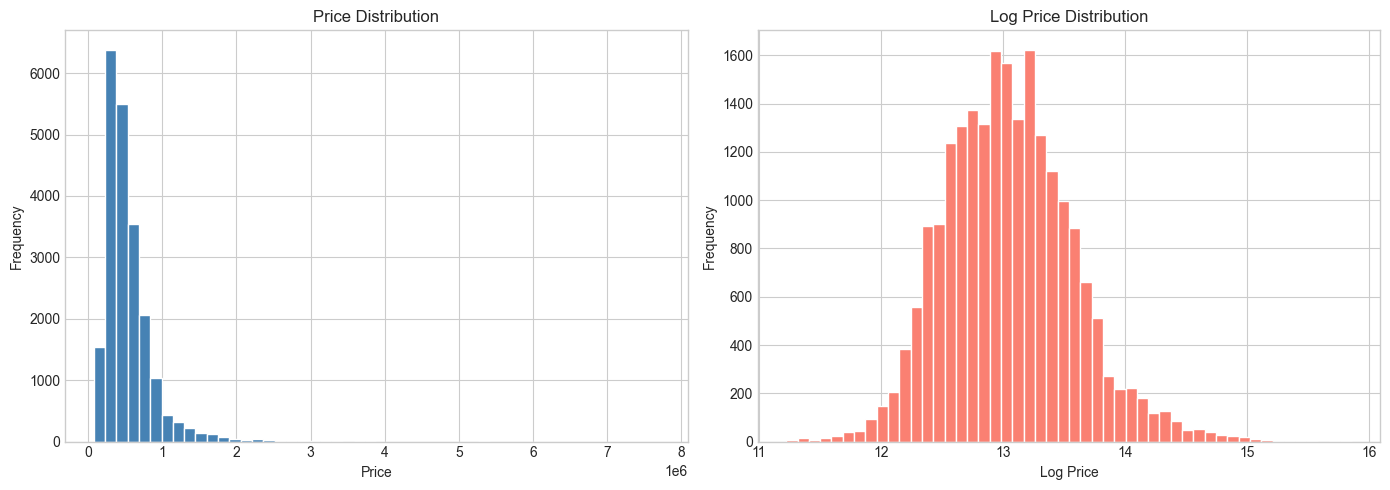

In [26]:
#Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['price']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

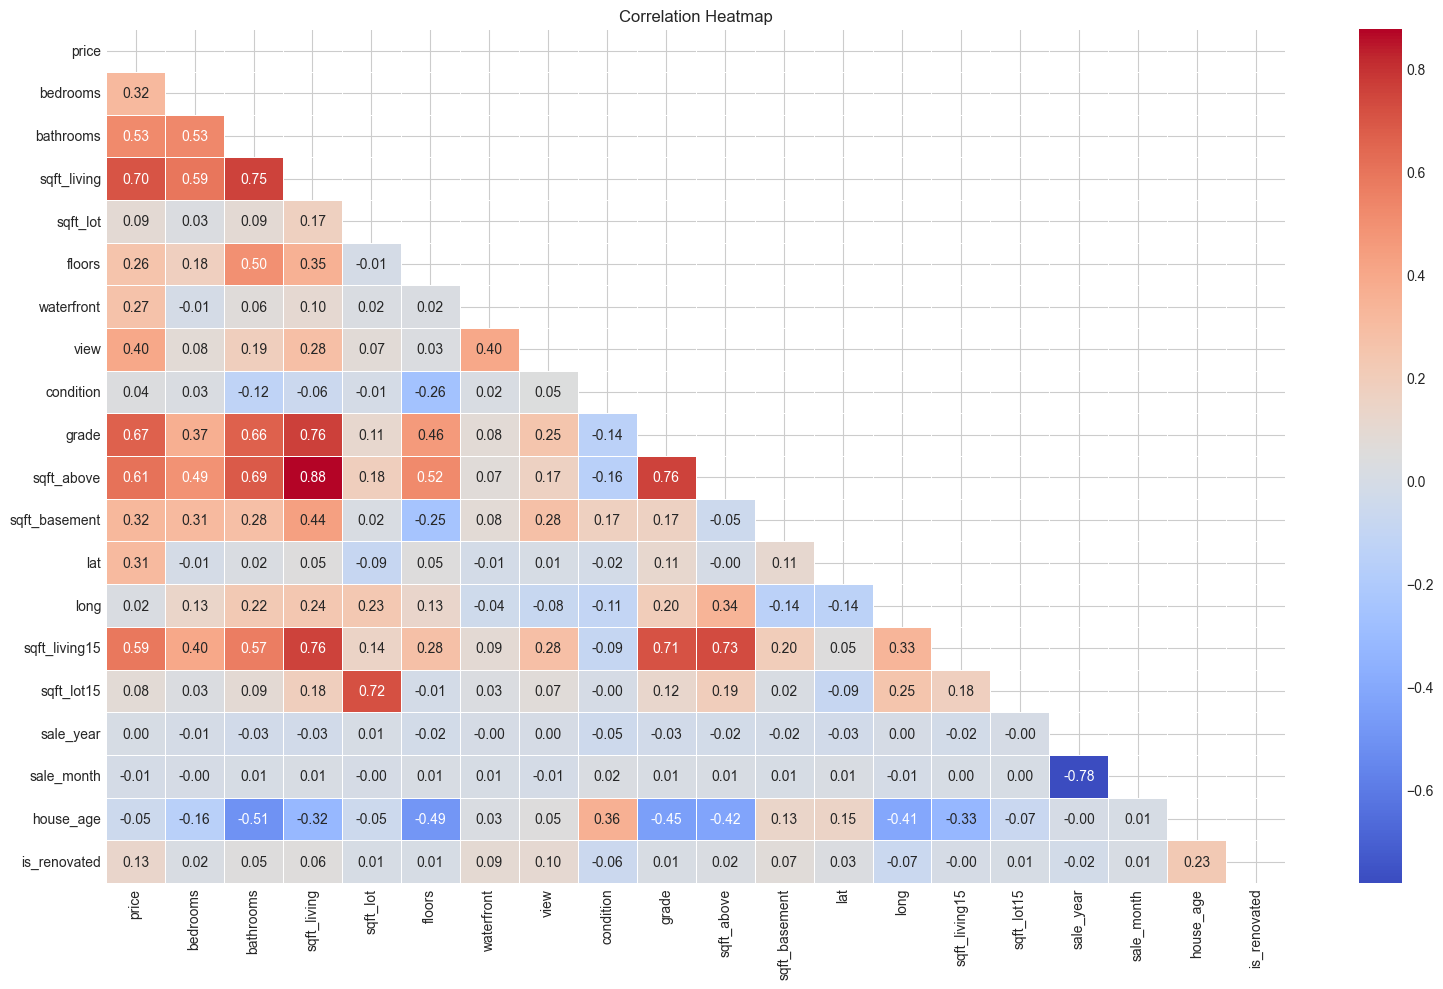

In [27]:
#Correlation Heatmap
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

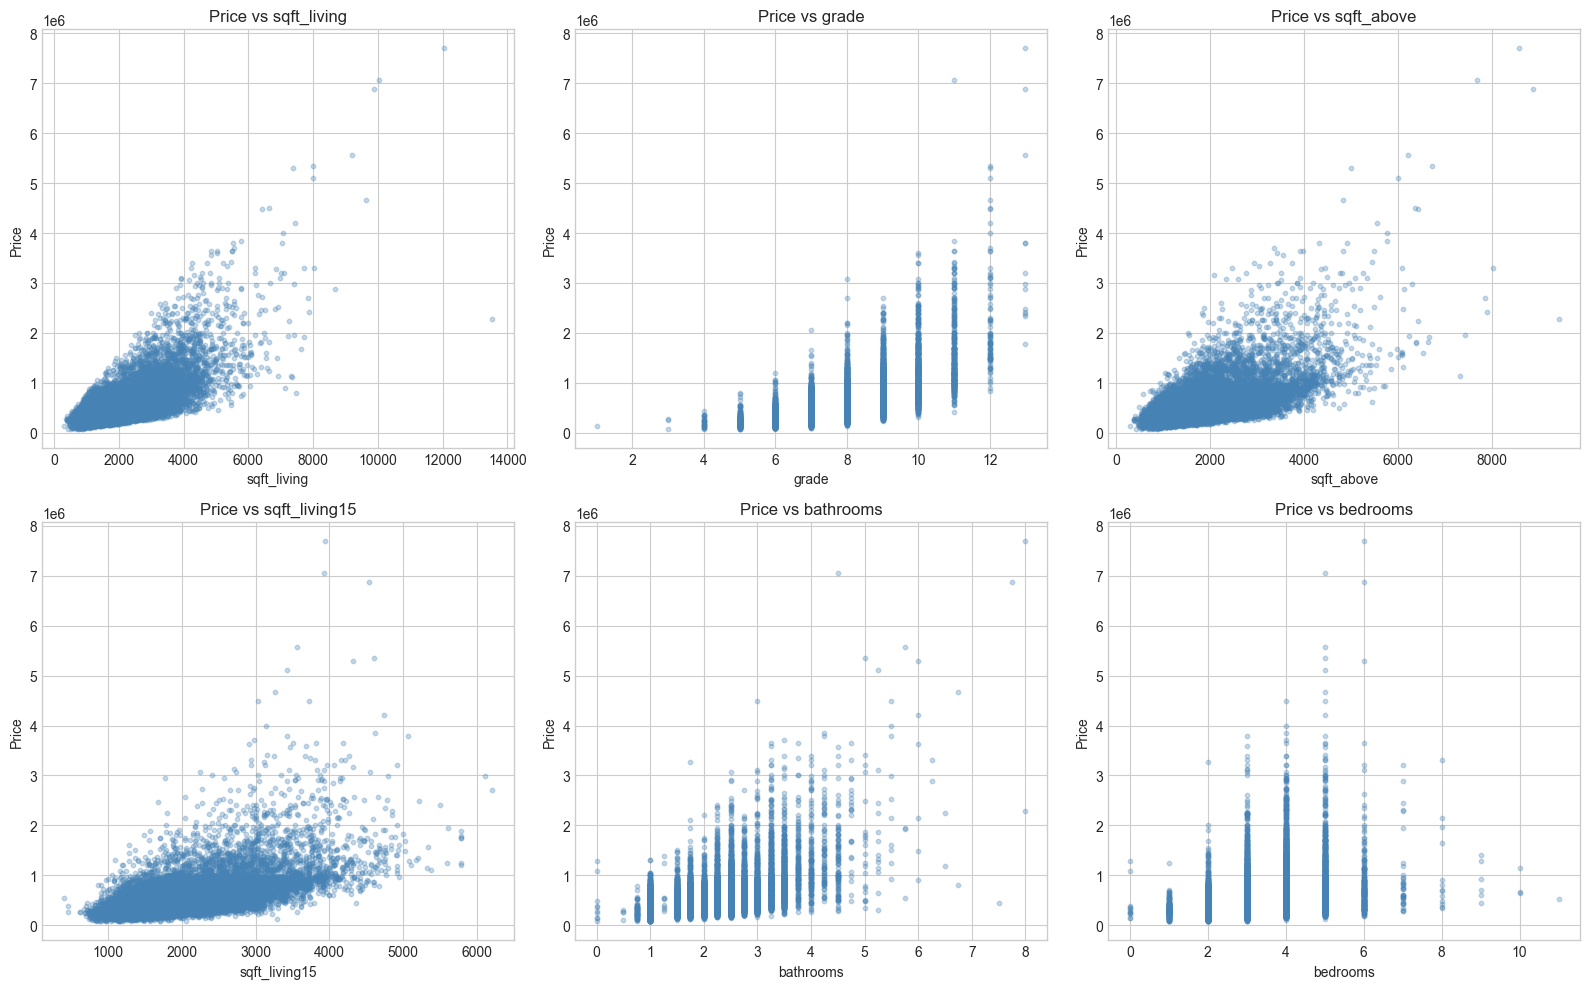

In [29]:
#Price vs Top Features
top_features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'bedrooms']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['price'], alpha=0.3, color='steelblue', s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Price vs {col}')

plt.tight_layout()
plt.savefig('../reports/figures/price_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

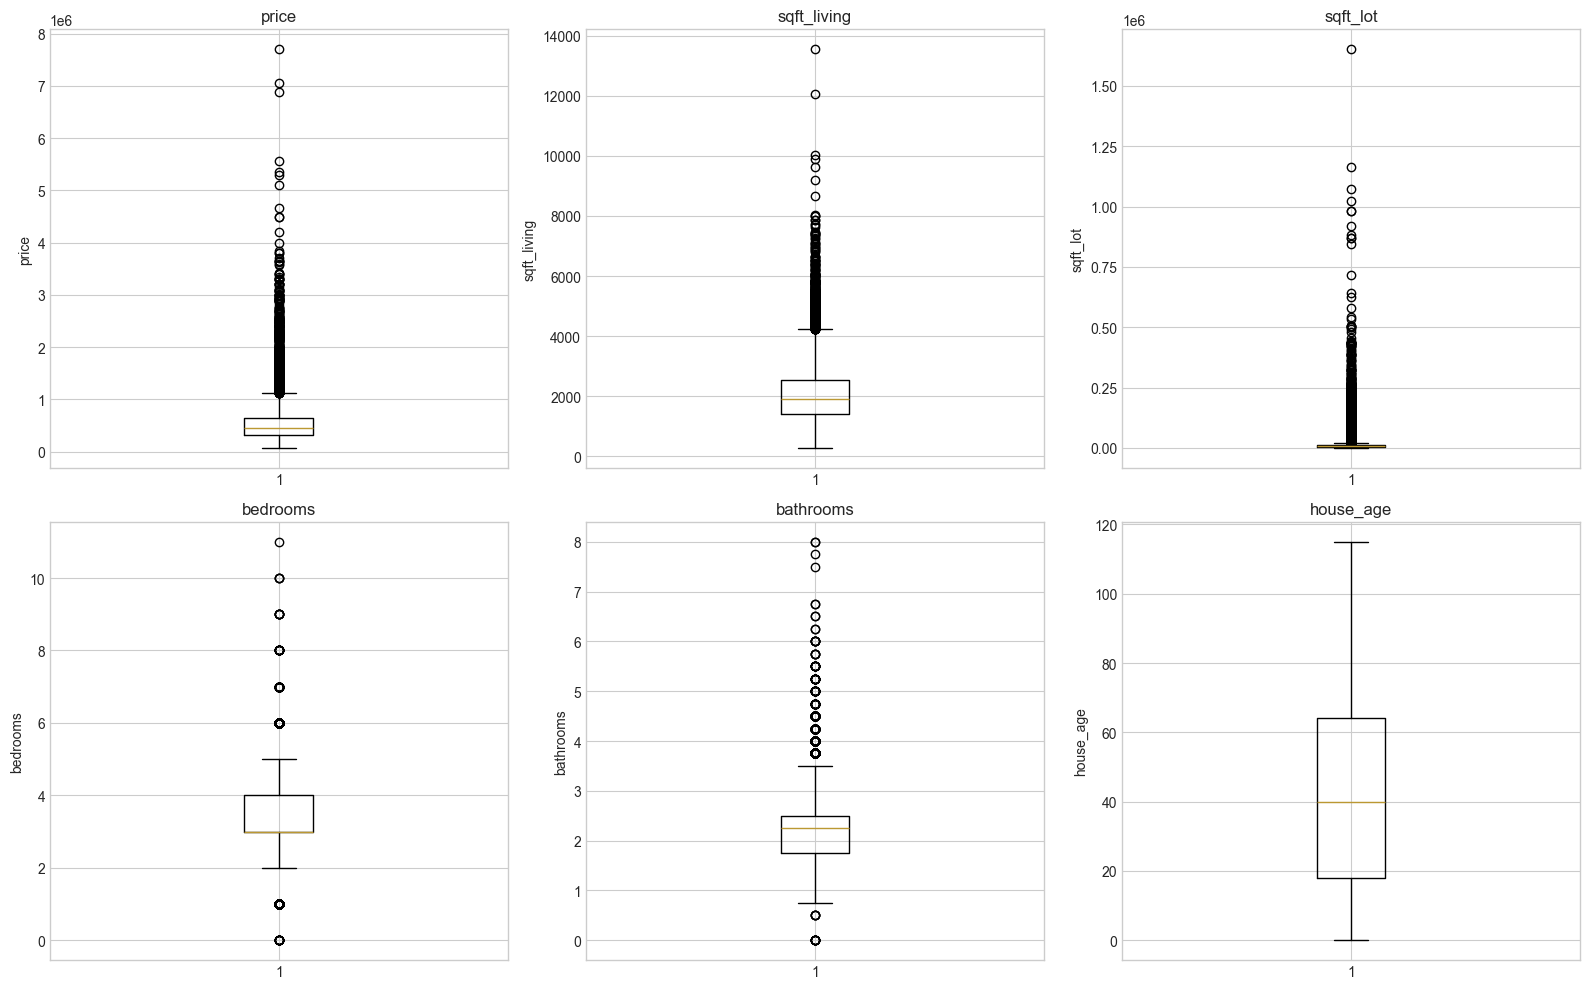

In [28]:
#Boxplot Outlier Check
cols = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'house_age']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('../reports/figures/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

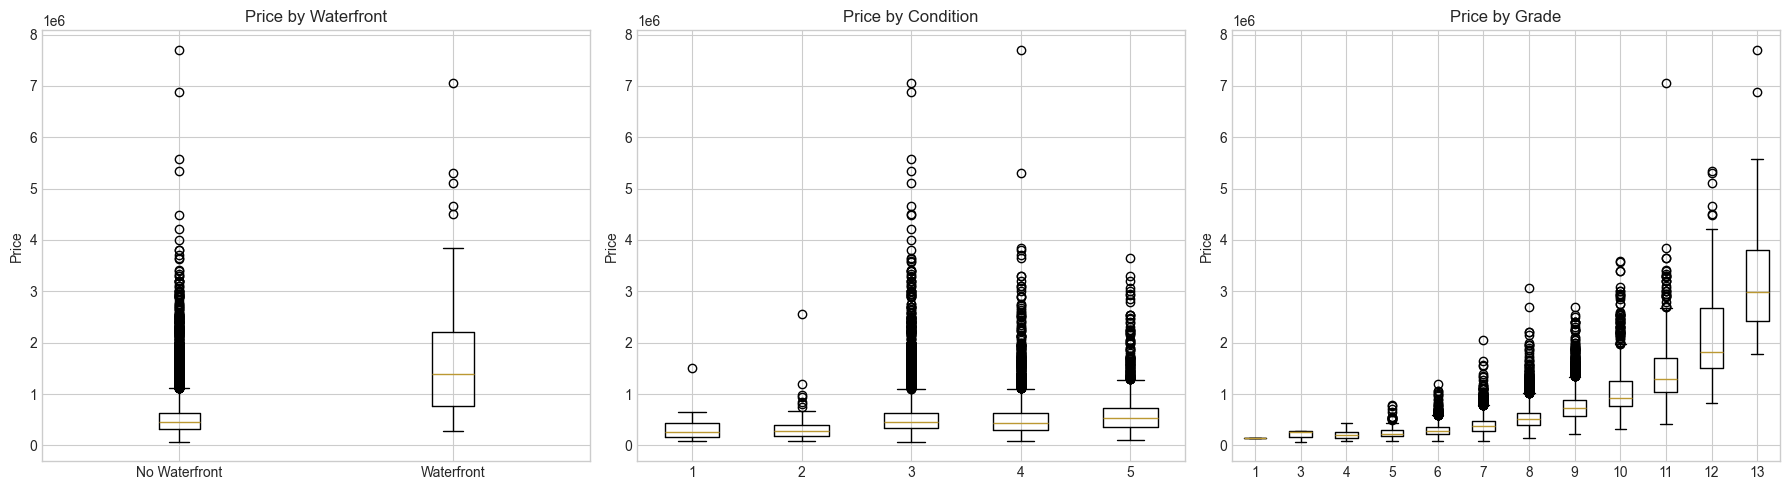

In [32]:
# Price by Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# price by waterfront
axes[0].boxplot([df[df['waterfront']==0]['price'], df[df['waterfront']==1]['price']],
                labels=['No Waterfront', 'Waterfront'])
axes[0].set_title('Price by Waterfront')
axes[0].set_ylabel('Price')

# price by condition
conditions = sorted(df['condition'].unique())
axes[1].boxplot([df[df['condition']==c]['price'] for c in conditions], labels=conditions)
axes[1].set_title('Price by Condition')
axes[1].set_ylabel('Price')

# price by grade
grades = sorted(df['grade'].unique())
axes[2].boxplot([df[df['grade']==g]['price'] for g in grades], labels=grades)
axes[2].set_title('Price by Grade')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.savefig('../reports/figures/price_by_categories.png', dpi=150, bbox_inches='tight')
plt.show()

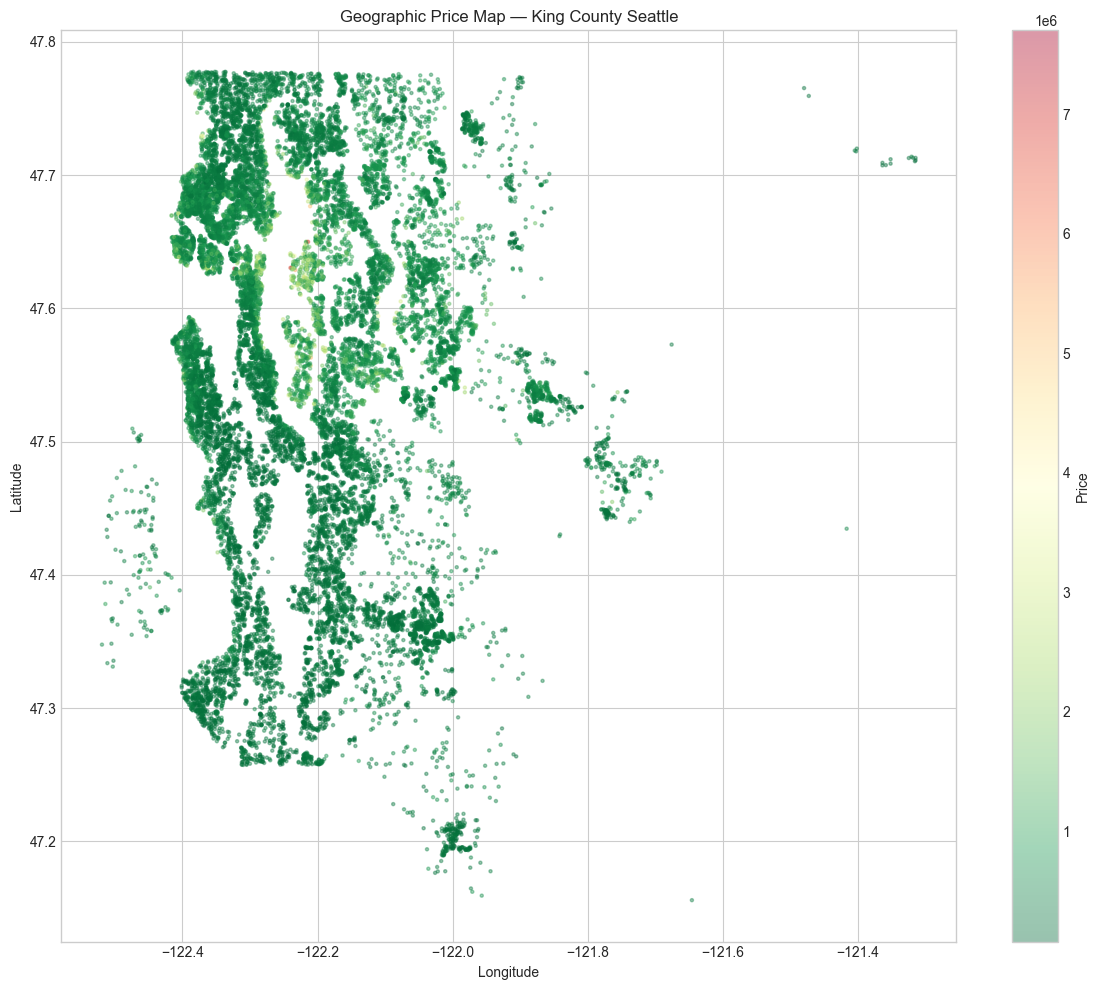

In [33]:
#Geographic Price Map
plt.figure(figsize=(12, 10))
scatter = plt.scatter(df['long'], df['lat'], 
                      c=df['price'], 
                      cmap='RdYlGn_r',
                      alpha=0.4, 
                      s=5)
plt.colorbar(scatter, label='Price')
plt.title('Geographic Price Map — King County Seattle')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../reports/figures/geographic_price_map.png', dpi=150, bbox_inches='tight')
plt.show()

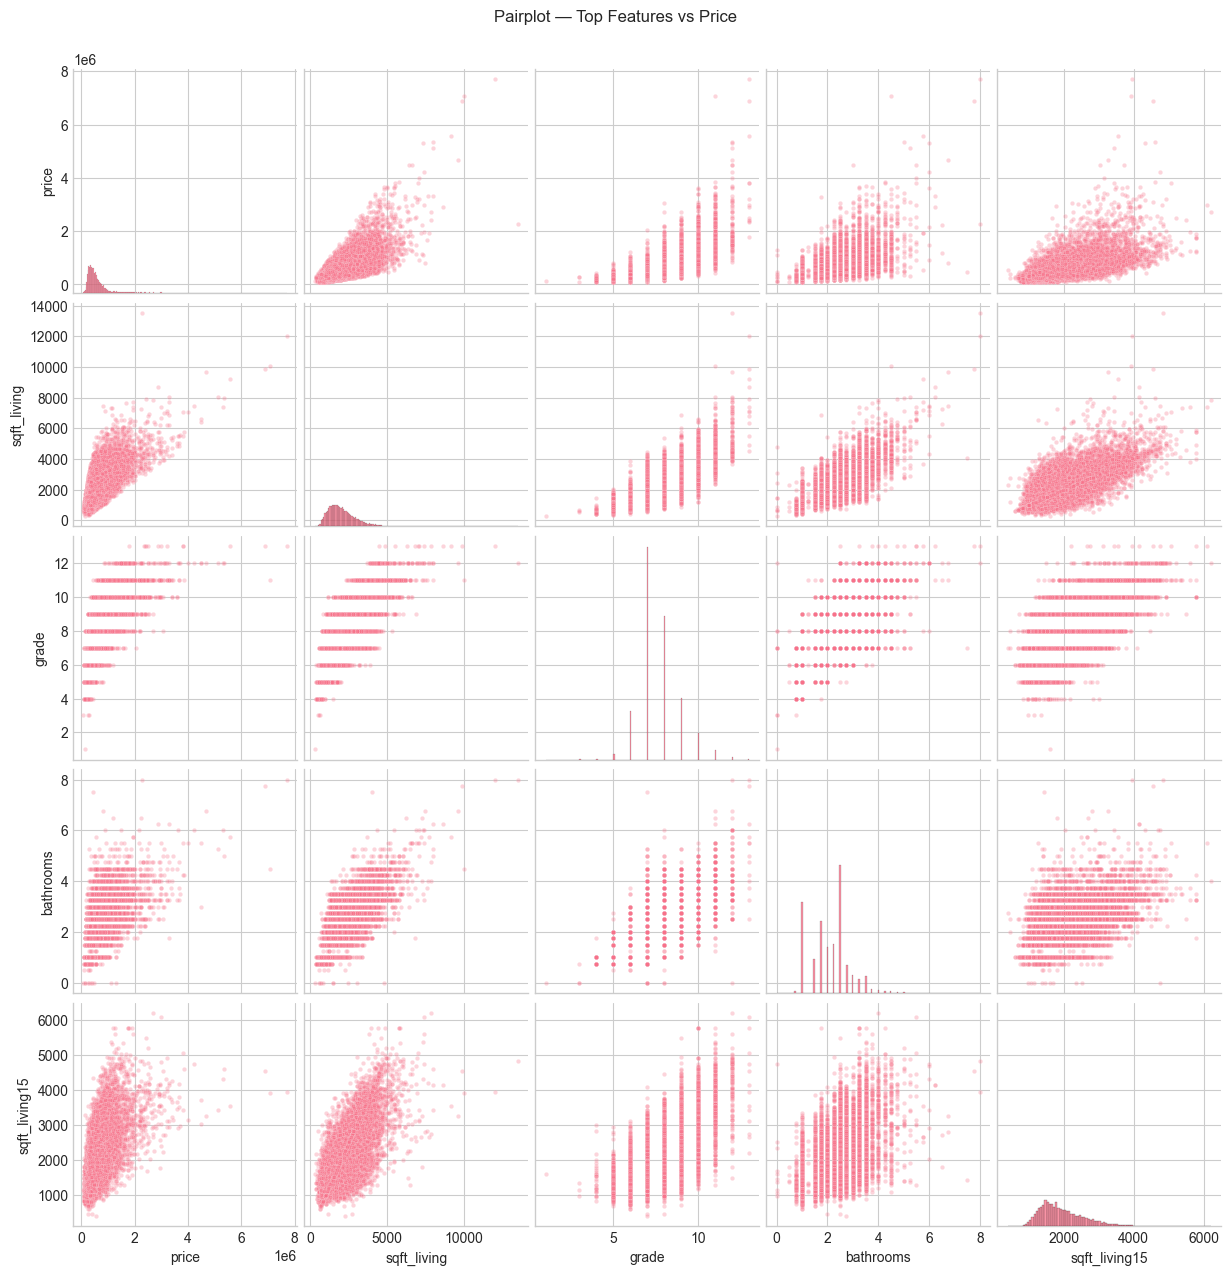

In [34]:
#Pairplot Top 5 Features
top_cols = ['price', 'sqft_living', 'grade', 'bathrooms', 'sqft_living15']
sns.pairplot(df[top_cols], plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot — Top Features vs Price', y=1.02)
plt.savefig('../reports/figures/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Feature Engineering


In [35]:
#Drop high multicollinearity columns
# sqft_above has 0.88 correlation with sqft_living — drop it
# sqft_lot15 has 0.72 correlation with sqft_lot — drop it
df.drop(columns=['sqft_above', 'sqft_lot15'], inplace=True)

print("Shape after dropping multicollinear columns:", df.shape)
print("Columns:", list(df.columns))

Shape after dropping multicollinear columns: (21612, 18)
Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sale_year', 'sale_month', 'house_age', 'is_renovated']


In [36]:
#Create new features

# price per sqft
df['price_per_sqft'] = df['price'] / df['sqft_living']

# total rooms
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

# living area ratio — how much of neighbors living area is this house
df['living_area_ratio'] = df['sqft_living'] / df['sqft_living15']

print("Shape after feature engineering:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape after feature engineering: (21612, 21)
Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sale_year', 'sale_month', 'house_age', 'is_renovated', 'price_per_sqft', 'total_rooms', 'living_area_ratio']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,lat,long,sqft_living15,sale_year,sale_month,house_age,is_renovated,price_per_sqft,total_rooms,living_area_ratio
0,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,0,47.51,-122.26,1340,2014,10,60,0,188.05,4.00,0.88
1,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,400,47.72,-122.32,1690,2014,12,64,1,209.34,5.25,1.52
2,180000.00,2,1.00,770,10000,1.00,0,0,3,6,0,47.74,-122.23,2720,2015,2,82,0,233.77,3.00,0.28
3,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,910,47.52,-122.39,1360,2014,12,50,0,308.16,7.00,1.44
4,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,0,47.62,-122.05,1800,2015,2,28,0,303.57,5.00,0.93


In [37]:
#Create log price target

df['log_price'] = np.log1p(df['price'])

print("Price stats:")
print(f"  min : {df['price'].min()}")
print(f"  max : {df['price'].max()}")
print(f"\nLog Price stats:")
print(f"  min : {df['log_price'].min():.4f}")
print(f"  max : {df['log_price'].max():.4f}")

Price stats:
  min : 75000.0
  max : 7700000.0

Log Price stats:
  min : 11.2253
  max : 15.8567


In [38]:
#Final feature set

# drop original price, keep log_price as target
target = df['log_price']
features = df.drop(columns=['price', 'log_price', 'price_per_sqft'])

print("Features shape:", features.shape)
print("Target shape:", target.shape)
print("\nFeature columns:")
print(list(features.columns))

Features shape: (21612, 19)
Target shape: (21612,)

Feature columns:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sale_year', 'sale_month', 'house_age', 'is_renovated', 'total_rooms', 'living_area_ratio']


## Step 7: Preprocessing


In [39]:
#Train/Test Split
X = features.values
y = target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (17289, 19)
X_test  : (4323, 19)
y_train : (17289,)
y_test  : (4323,)


In [40]:
#Standardization from scratch

# compute mean and std from training data only
# never use test data statistics — data leakage
train_mean = np.mean(X_train, axis=0)
train_std  = np.std(X_train, axis=0)

# standardize: z = (x - mean) / std
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled  = (X_test  - train_mean) / train_std

print("Standardization done from scratch")
print(f"\nX_train_scaled mean (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"\nX_train_scaled std  (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

Standardization done from scratch

X_train_scaled mean (should be ~0): [-0. -0.  0.  0.  0. -0. -0.  0. -0.  0. -0.  0.  0. -0.  0. -0.  0. -0.
  0.]

X_train_scaled std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [41]:
#Add bias term

# add column of ones for bias/intercept term
# X becomes [1, x1, x2, ..., xn]
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final  = np.c_[np.ones(X_test_scaled.shape[0]),  X_test_scaled]

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape : {X_test_final.shape}")

X_train_final shape: (17289, 20)
X_test_final shape : (4323, 20)


## Step 8: Linear Regression from Scratch


In [42]:
#Normal Equation:
class LinearRegressionNormalEquation:
    """
    Linear Regression using Normal Equation.
    w = (X^T X)^-1 X^T y
    """
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # w = (X^T X)^-1 X^T y
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        return X @ self.weights


ne_model = LinearRegressionNormalEquation()
ne_model.fit(X_train_final, y_train)
y_pred_ne = ne_model.predict(X_test_final)

print("Normal Equation model trained successfully")
print(f"Weights shape: {ne_model.weights.shape}")
print(f"First 5 predictions : {y_pred_ne[:5].round(4)}")
print(f"First 5 actual      : {y_test[:5].round(4)}")

Normal Equation model trained successfully
Weights shape: (20,)
First 5 predictions : [12.9691 13.477  14.0132 13.1643 12.7953]
First 5 actual      : [12.8077 13.6705 13.8528 13.2879 12.7737]


In [43]:
#Gradient Descent
class LinearRegressionGradientDescent:
    """
    Linear Regression using Gradient Descent.
    w = w - lr * (1/n) * X^T (Xw - y)
    """
    def __init__(self, lr=0.01, n_iterations=1000):
        self.lr           = lr
        self.n_iterations = n_iterations
        self.weights      = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        for i in range(self.n_iterations):
            # predictions
            y_pred = X @ self.weights

            # error
            error = y_pred - y

            # gradient
            gradient = (1 / n_samples) * X.T @ error

            # update weights
            self.weights -= self.lr * gradient

            # compute and store loss (MSE)
            loss = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.loss_history.append(loss)

            if i % 100 == 0:
                print(f"Iteration {i:4d} | Loss: {loss:.6f}")

        return self

    def predict(self, X):
        return X @ self.weights


gd_model = LinearRegressionGradientDescent(lr=0.01, n_iterations=1000)
gd_model.fit(X_train_final, y_train)
y_pred_gd = gd_model.predict(X_test_final)

print("\nGradient Descent model trained successfully")
print(f"Weights shape: {gd_model.weights.shape}")
print(f"First 5 predictions : {y_pred_gd[:5].round(4)}")
print(f"First 5 actual      : {y_test[:5].round(4)}")

Iteration    0 | Loss: 85.242352
Iteration  100 | Loss: 11.438993
Iteration  200 | Loss: 1.560255
Iteration  300 | Loss: 0.236564
Iteration  400 | Loss: 0.059121
Iteration  500 | Loss: 0.035297
Iteration  600 | Loss: 0.032077
Iteration  700 | Loss: 0.031630
Iteration  800 | Loss: 0.031560
Iteration  900 | Loss: 0.031544

Gradient Descent model trained successfully
Weights shape: (20,)
First 5 predictions : [12.9653 13.4827 14.0101 13.1566 12.7977]
First 5 actual      : [12.8077 13.6705 13.8528 13.2879 12.7737]


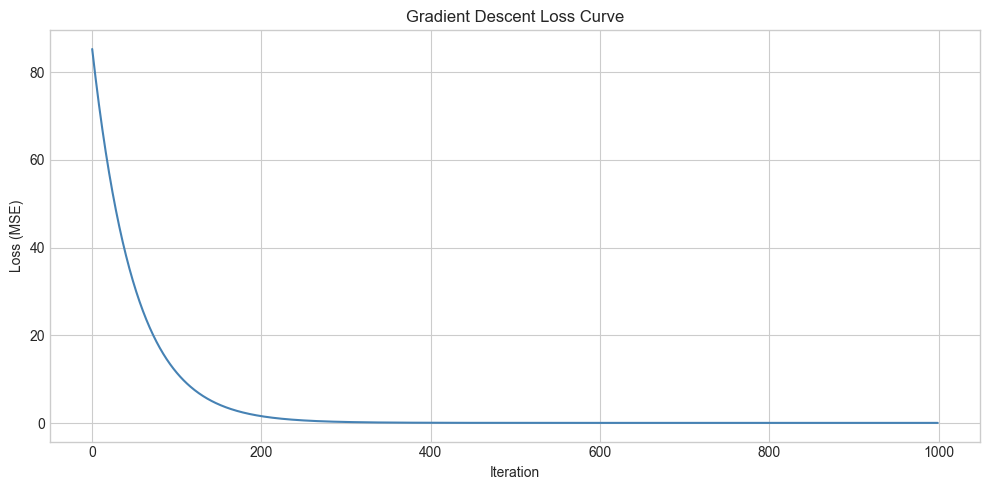

In [44]:
#Plot Gradient Descent Loss Curve

plt.figure(figsize=(10, 5))
plt.plot(gd_model.loss_history, color='steelblue')
plt.title('Gradient Descent Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.tight_layout()
plt.savefig('../reports/figures/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
### Sklearn Linear Regression (for comparison)
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train_final, y_train)
y_pred_sk = sk_model.predict(X_test_final)

print("Sklearn model trained successfully")
print(f"First 5 predictions : {y_pred_sk[:5].round(4)}")
print(f"First 5 actual      : {y_test[:5].round(4)}")

Sklearn model trained successfully
First 5 predictions : [12.9692 13.4767 14.0131 13.1639 12.7953]
First 5 actual      : [12.8077 13.6705 13.8528 13.2879 12.7737]


## Step 9: Evaluation


In [46]:
#Metrics from scratch
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

print("Metrics functions defined successfully")

Metrics functions defined successfully


In [48]:
results = {
    'Normal Equation': {
        'MSE'  : mse(y_test, y_pred_ne),
        'RMSE' : rmse(y_test, y_pred_ne),
        'MAE'  : mae(y_test, y_pred_ne),
        'R2'   : r2(y_test, y_pred_ne)
    },
    'Gradient Descent': {
        'MSE'  : mse(y_test, y_pred_gd),
        'RMSE' : rmse(y_test, y_pred_gd),
        'MAE'  : mae(y_test, y_pred_gd),
        'R2'   : r2(y_test, y_pred_gd)
    },
    'Sklearn': {
        'MSE'  : mse(y_test, y_pred_sk),
        'RMSE' : rmse(y_test, y_pred_sk),
        'MAE'  : mae(y_test, y_pred_sk),
        'R2'   : r2(y_test, y_pred_sk)
    }
}

results_df = pd.DataFrame(results).T.round(6)
print("Model Comparison:")
print(results_df)

Model Comparison:
                  MSE  RMSE  MAE   R2
Normal Equation  0.07  0.26 0.20 0.77
Gradient Descent 0.07  0.26 0.20 0.77
Sklearn          0.07  0.26 0.20 0.77


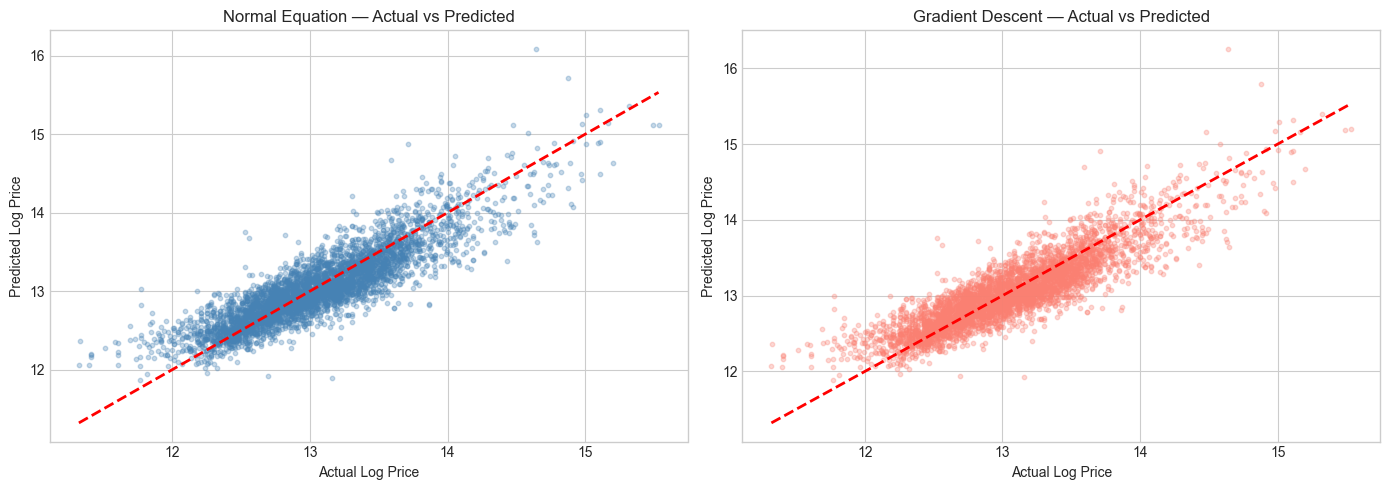

In [49]:
#Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# normal equation
axes[0].scatter(y_test, y_pred_ne, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Normal Equation — Actual vs Predicted')
axes[0].set_xlabel('Actual Log Price')
axes[0].set_ylabel('Predicted Log Price')

# gradient descent
axes[1].scatter(y_test, y_pred_gd, alpha=0.3, s=10, color='salmon')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Gradient Descent — Actual vs Predicted')
axes[1].set_xlabel('Actual Log Price')
axes[1].set_ylabel('Predicted Log Price')

plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

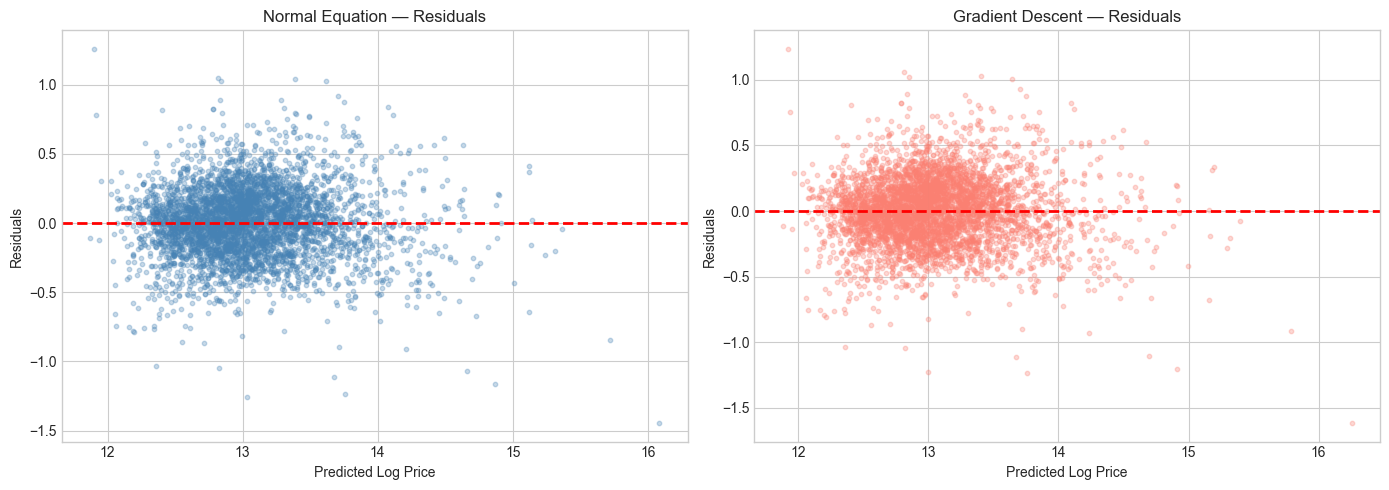

In [50]:
#Residual Plot
residuals_ne = y_test - y_pred_ne
residuals_gd = y_test - y_pred_gd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_ne, residuals_ne, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Normal Equation — Residuals')
axes[0].set_xlabel('Predicted Log Price')
axes[0].set_ylabel('Residuals')

axes[1].scatter(y_pred_gd, residuals_gd, alpha=0.3, s=10, color='salmon')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Gradient Descent — Residuals')
axes[1].set_xlabel('Predicted Log Price')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('../reports/figures/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

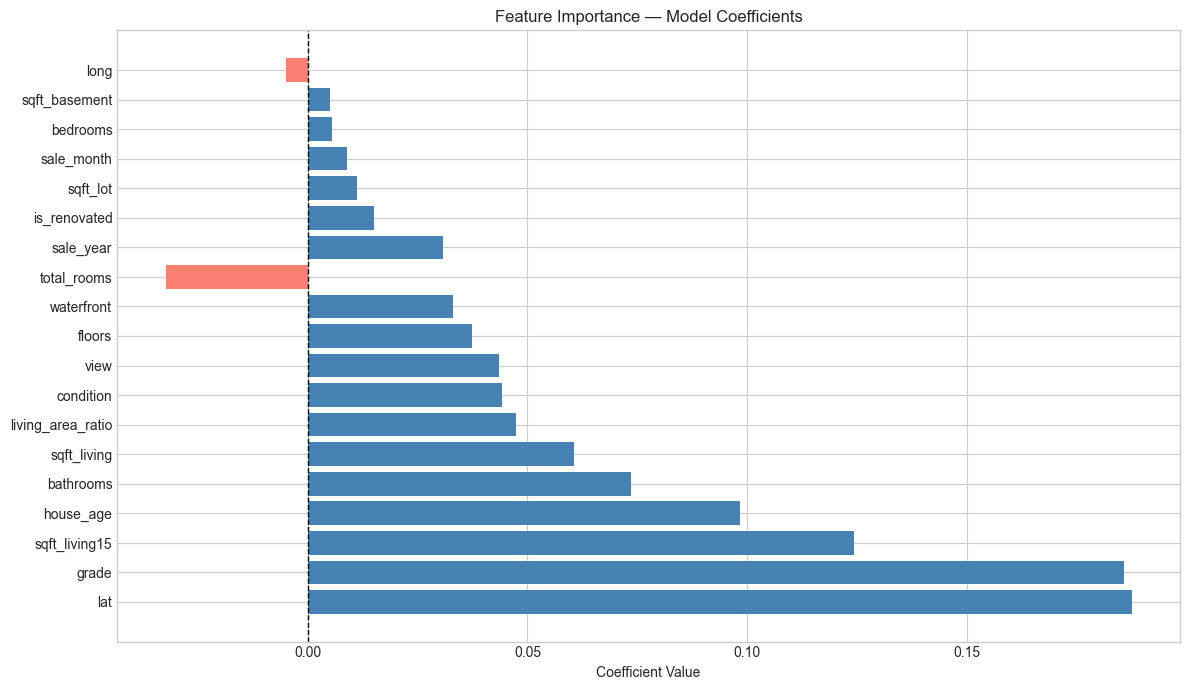

In [51]:
#Feature Importance (coefficients)
feature_names = ['bias'] + list(features.columns)
weights = ne_model.weights

coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': weights
}).iloc[1:]  # drop bias term

coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 7))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', lw=1)
plt.title('Feature Importance — Model Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

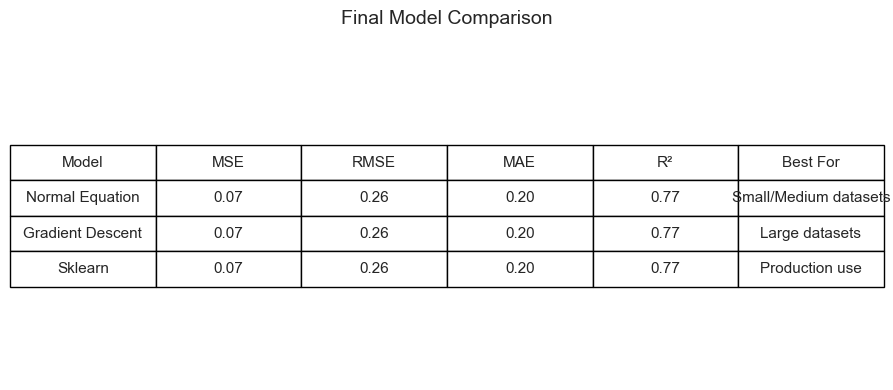

In [58]:
#model_comparison
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [
    ['Model', 'MSE', 'RMSE', 'MAE', 'R²', 'Best For'],
    ['Normal Equation', '0.07', '0.26', '0.20', '0.77', 'Small/Medium datasets'],
    ['Gradient Descent', '0.07', '0.26', '0.20', '0.77', 'Large datasets'],
    ['Sklearn', '0.07', '0.26', '0.20', '0.77', 'Production use'],
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.5, 2)

plt.title('Final Model Comparison', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Save Model


In [52]:
os.makedirs('../models', exist_ok=True)
print("Models directory ready")

Models directory ready


In [53]:
# Save Normal Equation model
ne_model_data = {
    'weights'    : ne_model.weights,
    'train_mean' : train_mean,
    'train_std'  : train_std,
    'features'   : list(features.columns)
}

with open('../models/ne_model.pkl', 'wb') as f:
    pickle.dump(ne_model_data, f)

print("Normal Equation model saved to ../models/ne_model.pkl")

Normal Equation model saved to ../models/ne_model.pkl


In [54]:
#Save Gradient Descent model
gd_model_data = {
    'weights'    : gd_model.weights,
    'train_mean' : train_mean,
    'train_std'  : train_std,
    'features'   : list(features.columns),
    'loss_history': gd_model.loss_history
}

with open('../models/gd_model.pkl', 'wb') as f:
    pickle.dump(gd_model_data, f)

print("Gradient Descent model saved to ../models/gd_model.pkl")

Gradient Descent model saved to ../models/gd_model.pkl


In [59]:
sk_model_data = {
    'model'      : sk_model,
    'train_mean' : train_mean,
    'train_std'  : train_std,
    'features'   : list(features.columns)
}

with open('../models/sk_model.pkl', 'wb') as f:
    pickle.dump(sk_model_data, f)

print("Sklearn model saved to ../models/sk_model.pkl")

Sklearn model saved to ../models/sk_model.pkl


In [55]:
#verification

with open('../models/ne_model.pkl', 'rb') as f:
    loaded_ne = pickle.load(f)

with open('../models/gd_model.pkl', 'rb') as f:
    loaded_gd = pickle.load(f)

print("Models loaded successfully")
print(f"\nNE model keys  : {list(loaded_ne.keys())}")
print(f"GD model keys  : {list(loaded_gd.keys())}")
print(f"\nNE weights shape : {loaded_ne['weights'].shape}")
print(f"GD weights shape : {loaded_gd['weights'].shape}")
print(f"\nFeatures : {loaded_ne['features']}")

Models loaded successfully

NE model keys  : ['weights', 'train_mean', 'train_std', 'features']
GD model keys  : ['weights', 'train_mean', 'train_std', 'features', 'loss_history']

NE weights shape : (20,)
GD weights shape : (20,)

Features : ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sale_year', 'sale_month', 'house_age', 'is_renovated', 'total_rooms', 'living_area_ratio']


In [56]:
#Test with custom data
def predict_price(input_dict, model_data):
    # create dataframe from input
    input_df = pd.DataFrame([input_dict])
    
    # make sure columns are in correct order
    input_df = input_df[model_data['features']]
    
    # standardize using saved train mean and std
    input_scaled = (input_df.values - model_data['train_mean']) / model_data['train_std']
    
    # add bias term
    input_final = np.c_[np.ones(1), input_scaled]
    
    # predict log price
    log_price = input_final @ model_data['weights']
    
    # convert back to actual price
    actual_price = np.expm1(log_price)
    
    return actual_price[0]


# custom house data
custom_house = {
    'bedrooms'         : 3,
    'bathrooms'        : 2.0,
    'sqft_living'      : 1800,
    'sqft_lot'         : 7000,
    'floors'           : 1.0,
    'waterfront'       : 0,
    'view'             : 0,
    'condition'        : 3,
    'grade'            : 7,
    'sqft_basement'    : 0,
    'lat'              : 47.5,
    'long'             : -122.2,
    'sqft_living15'    : 1800,
    'sale_year'        : 2015,
    'sale_month'       : 6,
    'house_age'        : 30,
    'is_renovated'     : 0,
    'total_rooms'      : 5.0,
    'living_area_ratio': 1.0
}

predicted_price = predict_price(custom_house, loaded_ne)
print(f"Custom House Predicted Price : ${predicted_price:,.0f}")

Custom House Predicted Price : $330,076


In [57]:
houses = [
    {
        'name': 'Small Budget House',
        'bedrooms': 2, 'bathrooms': 1.0, 'sqft_living': 900,
        'sqft_lot': 5000, 'floors': 1.0, 'waterfront': 0,
        'view': 0, 'condition': 2, 'grade': 5,
        'sqft_basement': 0, 'lat': 47.3, 'long': -122.3,
        'sqft_living15': 900, 'sale_year': 2015, 'sale_month': 6,
        'house_age': 60, 'is_renovated': 0, 'total_rooms': 3.0,
        'living_area_ratio': 1.0
    },
    {
        'name': 'Luxury Waterfront House',
        'bedrooms': 5, 'bathrooms': 4.0, 'sqft_living': 5000,
        'sqft_lot': 20000, 'floors': 3.0, 'waterfront': 1,
        'view': 4, 'condition': 5, 'grade': 12,
        'sqft_basement': 1000, 'lat': 47.7, 'long': -122.2,
        'sqft_living15': 4000, 'sale_year': 2015, 'sale_month': 6,
        'house_age': 10, 'is_renovated': 1, 'total_rooms': 9.0,
        'living_area_ratio': 1.25
    },
    {
        'name': 'Average Family House',
        'bedrooms': 4, 'bathrooms': 2.5, 'sqft_living': 2200,
        'sqft_lot': 8000, 'floors': 2.0, 'waterfront': 0,
        'view': 0, 'condition': 3, 'grade': 8,
        'sqft_basement': 500, 'lat': 47.5, 'long': -122.1,
        'sqft_living15': 2000, 'sale_year': 2015, 'sale_month': 6,
        'house_age': 25, 'is_renovated': 0, 'total_rooms': 6.5,
        'living_area_ratio': 1.1
    }
]

print("House Price Predictions")
print("-" * 40)
for house in houses:
    name = house.pop('name')
    price = predict_price(house, loaded_ne)
    print(f"{name:30s} : ${price:>12,.0f}")

House Price Predictions
----------------------------------------
Small Budget House             : $     143,232
Luxury Waterfront House        : $   5,131,212
Average Family House           : $     450,968
